# WITH PANDAS AND MATPLOTLIB

In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore') 
%matplotlib inline

INSTRUCTIONS

1. Number of people by gender
1. Kill weapon
1. Age of killed people
1. Race of killed people
1. Killed People According to Races (Pie Chart)
1. Most common 15 Name or Surname of killed people

<br>

read data

if didn't work you can use this parameters: encoding="windows-1252"

In [3]:
kill = pd.read_csv('PoliceKillingsUS.csv', encoding="windows-1252")

## 1: Plot number of people by gender

In [4]:
kill.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [5]:
len(kill[kill['gender'] == 'M'])

2428

In [116]:
kill.shape

(2535, 14)

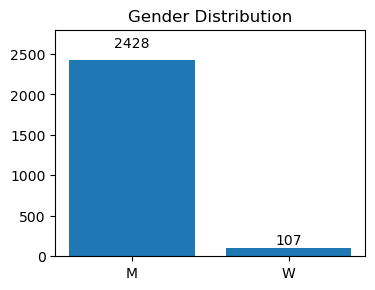

In [6]:
# with matplotlib

fig, ax = plt.subplots(figsize=(4, 3), dpi=100)

bar_x = [1,2]
bar_height = [ len(kill[kill['gender'] == 'M']) , len(kill[kill['gender'] == 'F']) ]
bar_tick_label = ['M','W']
bar_label = [ len(kill[kill['gender'] == 'M']) , len(kill[kill['gender'] == 'F']) ]

bar_plot = plt.bar(bar_x,bar_height,tick_label=bar_tick_label)

def autolabel(rects):
    for idx , rect in enumerate(bar_plot):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., 1.05*height,
                bar_label[idx],
                ha='center', va='bottom', rotation=0)

autolabel(bar_plot)

plt.ylim(0,2800)

plt.title('Gender Distribution')
plt.show()

## 2: Plot 7 most common kill weapons

In [7]:
common_kill_weapons = pd.DataFrame(kill['armed'].value_counts().head(7))
common_kill_weapons = common_kill_weapons.reset_index()
common_kill_weapons

,index,armed
0,gun,1398
1,knife,373
2,vehicle,177
3,unarmed,171
4,undetermined,117
5,toy weapon,104
6,machete,18


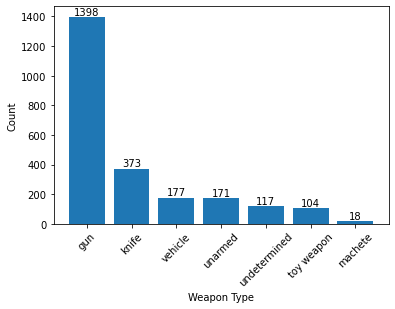

In [29]:
n= common_kill_weapons.loc[:,"index"]
s= common_kill_weapons.loc[:,"armed"]
line = plt.bar(n,s)
plt.xlabel('Weapon Type')
plt.ylabel("Count")

for i in range(len(s)):
    plt.annotate(str(s[i]), xy=(n[i],s[i]), ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

## 3: Plot number of age of killed people under two groups : Under 25 and Above 25

In [15]:
above_25 = kill[kill['age'] > 25]
above_25.head(5)

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False
7,15,Brock Nichols,06/01/15,shot,gun,35.0,M,W,Assaria,KS,False,attack,Not fleeing,False


In [16]:
under_25 = kill[kill['age'] < 25]
under_25.head(5)

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
5,11,Kenneth Joe Brown,04/01/15,shot,gun,18.0,M,W,Guthrie,OK,False,attack,Not fleeing,False
6,13,Kenneth Arnold Buck,05/01/15,shot,gun,22.0,M,H,Chandler,AZ,False,attack,Car,False
22,43,Brian Barbosa,11/01/15,shot,gun,23.0,M,H,South Gate,CA,False,attack,Not fleeing,False
26,49,Marcus Golden,14/01/15,shot,vehicle,24.0,M,B,St. Paul,MN,False,attack,Not fleeing,False


In [19]:
above_25.shape

(1905, 14)

In [20]:
under_25.shape

(450, 14)

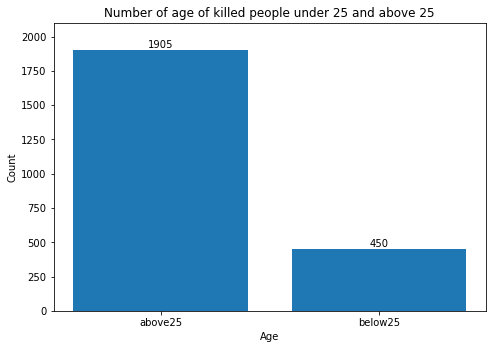

In [41]:
# with matplotlib
fig1 = plt.figure()
ax = fig1.add_axes([0,0,1,1])
groups = ['above25', 'below25']
counts = [len(above_25['age']),len(under_25['age'])]
ax.bar(groups,counts)
for i in range(len(counts)):
    plt.annotate(str(counts[i]), xy=(groups[i],counts[i]), ha='center', va='bottom')
plt.ylim(0,2100)
plt.title('Number of age of killed people under 25 and above 25')
plt.xlabel('Age')
plt.ylabel("Count")
plt.show()

## 4: Plot number of killed poeple by race

In [137]:
byrace = pd.DataFrame(kill['race'].value_counts())
byrace = byrace.reset_index()
byrace = byrace.rename(columns={"index": "race", "race": "counts"})
byrace

,race,counts
0,W,1201
1,B,618
2,H,423
3,A,39
4,N,31
5,O,28


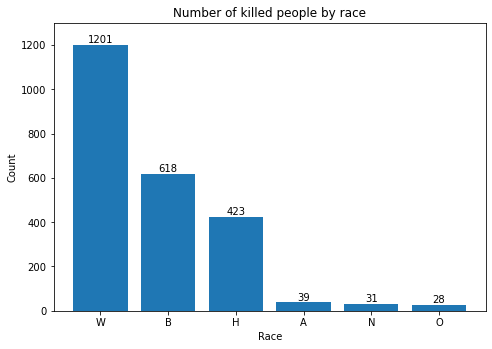

In [138]:
# with matplotlib
fig2 = plt.figure()
ax = fig2.add_axes([0,0,1,1])
races = byrace.iloc[:,0]
countss = byrace.iloc[:,1]
ax.bar(races,countss)
for i in range(len(countss)):
    plt.annotate(str(countss[i]), xy=(races[i],countss[i]), ha='center', va='bottom')
plt.ylim(0,1300)
plt.title('Number of killed people by race')
plt.xlabel('Race')
plt.ylabel("Count")
plt.show()

## 5: Killed People According to Races (Pie Chart)

In [104]:
kill.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [106]:
kill.race.unique()

array(['A', 'W', 'H', 'B', 'O', nan, 'N'], dtype=object)

In [112]:
kill['race'].isnull().sum()

195

In [113]:
kill.race.value_counts(dropna=False)

W      1201
B       618
H       423
NaN     195
A        39
N        31
O        28
Name: race, dtype: int64

Problem: missing value on race column.

**INSTRUCTION-1: Drop the all raws that contain missing value (dropna)**

In [120]:
kill1 = kill.dropna(subset=['race'])

In [121]:
kill1.shape

(2340, 14)

(2254, 15)

**INSTRUCTION-2: Demonstrate Race Ratio of Killed People by a Pie Chart (You can use Matplotlib)**

In [122]:
kill1.race.value_counts(dropna=False)

W    1201
B     618
H     423
A      39
N      31
O      28
Name: race, dtype: int64

In [124]:
kill1.race.unique()

array(['A', 'W', 'H', 'B', 'O', 'N'], dtype=object)

In [139]:
byrace1 = pd.DataFrame(kill1['race'].value_counts())
byrace1 = byrace1.reset_index()
byrace1 = byrace1.rename(columns={"index": "race", "race": "counts"})
byrace1

,race,counts
0,W,1201
1,B,618
2,H,423
3,A,39
4,N,31
5,O,28


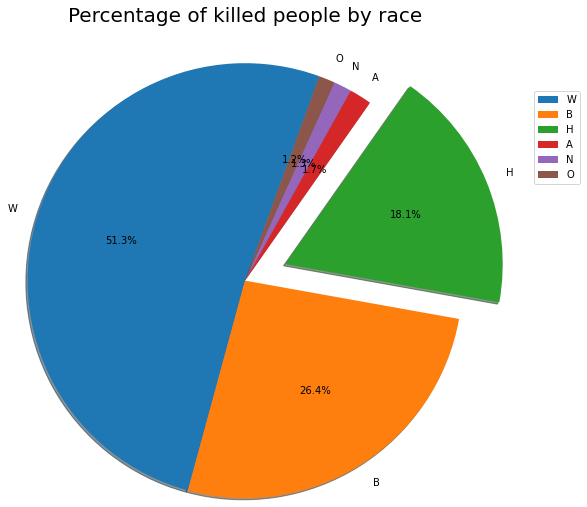

In [190]:
# matplotlib

races1 = byrace1.iloc[:,0]
countss1 = byrace1.iloc[:,1]
myexplode = [0, 0, 0.5, 0,0,0]

plt.axis('equal')
plt.title('Percentage of killed people by race',fontsize= 20, pad=150)
plt.pie(countss1, labels = races1,explode = myexplode,startangle = 70,autopct='%1.1f%%',shadow=True,radius=2.5)
plt.legend(races1, bbox_to_anchor=(1.3,1), loc="center right", fontsize=10, 
           bbox_transform=plt.gcf().transFigure)
plt.show() 